# BrushCue Example: 1990s Filter

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/1990s_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/1990s-filter

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


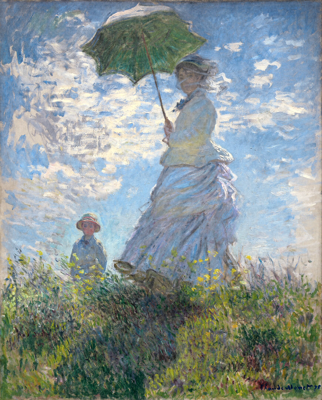

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
graded = (
    input_image.r_g_b_curve(
        bc.Curve.gamma(0.97), bc.Curve.gamma(0.96), bc.Curve.gamma(0.9)
    )
    .l_curve(bc.Curve.s_curve(0.5, 1.08, 1.0, 1.0))
    .saturation_adjust(1.04)
    .brightness_adjust(0.035)
)
bounds = input_image.bounds()
misregistered = graded.spacial_effect_shader(
    "let min_position = image_bounds.xy + vec2f(0.5);\nlet max_position = image_bounds.zw - vec2f(0.5);\nlet r = sample(clamp(position + vec2f(0.7, 0.0), min_position, max_position)).r;\nlet g = sample(position).g;\nlet b = sample(clamp(position - vec2f(0.5, 0.0), min_position, max_position)).b;\nlet a = sample(position).a;\nreturn vec4f(r, g, b, a);",
    "",
    1.0,
    bc.Dictionary.create().add("image_bounds", bounds),
    bc.ColorRepresentation.srgb(),
)
grained = misregistered.film_grain(2.2, 150.0, 0.5, 51.0, 0.3, 300.0, 0.32)
filtered = grained.vignette(
    bc.Vector2f.from_components((bounds.width() / 2.0), (bounds.height() / 2.0)),
    (bounds.width() / 2.0),
    (bounds.height() / 2.0),
    350.0,
    0.28,
).crop(bounds)
strength = 1.0
graph = (
    filtered.opacity_scales(strength)
    .blend_alpha(input_image, bc.Transform2.identity())
    .crop(bounds)
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
